In [ ]:
# ================================
# PHASE 3 : PROJECT INITIALIZATION
# ================================

from google.colab import drive
import pandas as pd
import os

# 1. Mount Google Drive
drive.mount("/content/drive")

# 2. Define base project path
BASE_DIR = "/content/drive/MyDrive/UP_Rainfall_Prediction_Project"

DATA_PATH = f"{BASE_DIR}/data/cleaned/merged_nasa_era5_daily_2017_2025.csv"

# 3. Check file existence
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError("Merged dataset not found. Phase 2 may be incomplete.")

# 4. Load merged dataset
df = pd.read_csv(DATA_PATH, parse_dates=["date"])

# 5. Basic validation
print("✅ Phase 3 dataset loaded successfully")
print("Shape:", df.shape)
print("Districts:", df['district'].nunique())
print("Date range:", df['date'].min(), "to", df['date'].max())
print("\nColumns:")
print(df.columns.tolist())

# 6. Preview
df.head()


Mounted at /content/drive
✅ Phase 3 dataset loaded successfully
Shape: (237688, 16)
Districts: 73
Date range: 2017-01-01 00:00:00 to 2025-11-30 00:00:00

Columns:
['date', 'PRECTOTCORR', 'RH2M', 'T2MDEW', 'PS', 'WS10M', 'WS50M', 'WD10M', 'WD50M', 'district', 't2m', 'd2m', 'sp', 'u10', 'v10', 'tp']


,date,PRECTOTCORR,RH2M,T2MDEW,PS,WS10M,WS50M,WD10M,WD50M,district,t2m,d2m,sp,u10,v10,tp
0,2017-01-01,0.0,58.76,6.32,99.68,2.26,3.34,104.4,107.4,agra,283.98868,283.34424,99542.47,-1.707794,0.345978,0.0
1,2017-01-02,0.0,57.88,6.45,99.87,2.28,3.33,354.9,354.0,agra,285.46164,285.15840,99623.60,-1.317856,-1.254608,0.0
2,2017-01-03,0.0,52.82,5.76,99.90,1.62,2.40,326.3,327.0,agra,284.18340,283.83905,99805.36,0.872009,-0.787140,0.0
3,2017-01-04,0.0,41.44,3.98,99.70,1.60,2.11,222.5,224.6,agra,282.85780,282.64444,99603.61,2.238419,0.960968,0.0
4,2017-01-05,0.0,35.74,2.01,99.56,1.87,2.56,251.0,249.4,agra,283.69406,283.31510,99517.44,0.115295,1.745438,0.0


In [ ]:
# ==========================================
# PHASE 3  TARGET & TIME FEATURES
# ==========================================

import numpy as np

# 1. Sort data properly
df = df.sort_values(["district", "date"]).reset_index(drop=True)

# 2. Create target variable (next-day rainfall from NASA)
df["rain_t_plus_1"] = (
    df.groupby("district")["PRECTOTCORR"]
      .shift(-1)
)

# 3. Extract time-based features
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["dayofweek"] = df["date"].dt.dayofweek

# 4. Drop last day per district (no target available)
df = df.dropna(subset=["rain_t_plus_1"]).reset_index(drop=True)

# 5. Quick verification
print("✅ Target & time features created")
print("New shape:", df.shape)
print("\nSample rows:")
df[["district", "date", "PRECTOTCORR", "rain_t_plus_1"]].head()


✅ Target & time features created
New shape: (237615, 21)

Sample rows:


,district,date,PRECTOTCORR,rain_t_plus_1
0,agra,2017-01-01,0.0,0.0
1,agra,2017-01-02,0.0,0.0
2,agra,2017-01-03,0.0,0.0
3,agra,2017-01-04,0.0,0.0
4,agra,2017-01-05,0.0,0.0


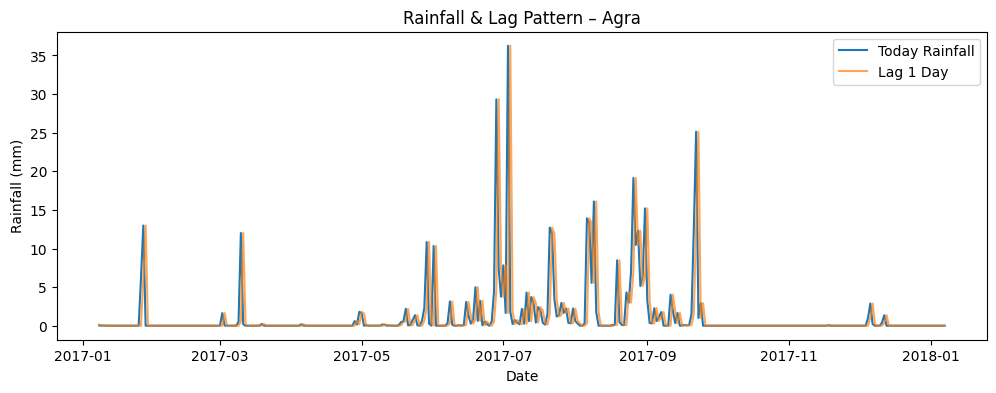

✅ Lag features created
New shape: (233856, 24)
   PRECTOTCORR  rain_lag_1  rain_lag_3  rain_lag_7
0         0.03        0.14        0.00         0.0
1         0.02        0.03        0.00         0.0
2         0.01        0.02        0.14         0.0
3         0.00        0.01        0.03         0.0
4         0.00        0.00        0.02         0.0


In [ ]:
# ==========================================
# PHASE 3  LAG FEATURES + VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt

# 1. Create lag rainfall features (NASA rainfall)
for lag in [1, 3, 7]:
    df[f"rain_lag_{lag}"] = (
        df.groupby("district")["PRECTOTCORR"]
          .shift(lag)
    )

# 2. Drop rows with missing lag values
df = df.dropna().reset_index(drop=True)

# 3. Visualization: rainfall time series for one sample district
sample_district = "agra"
sample_df = df[df["district"] == sample_district].iloc[:365]

plt.figure(figsize=(12, 4))
plt.plot(sample_df["date"], sample_df["PRECTOTCORR"], label="Today Rainfall")
plt.plot(sample_df["date"], sample_df["rain_lag_1"], label="Lag 1 Day", alpha=0.7)
plt.title(f"Rainfall & Lag Pattern – {sample_district.capitalize()}")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.show()

# 4. Verification
print("✅ Lag features created")
print("New shape:", df.shape)
print(df[["PRECTOTCORR", "rain_lag_1", "rain_lag_3", "rain_lag_7"]].head())


✅ Rolling rainfall features created
New shape: (233424, 28)


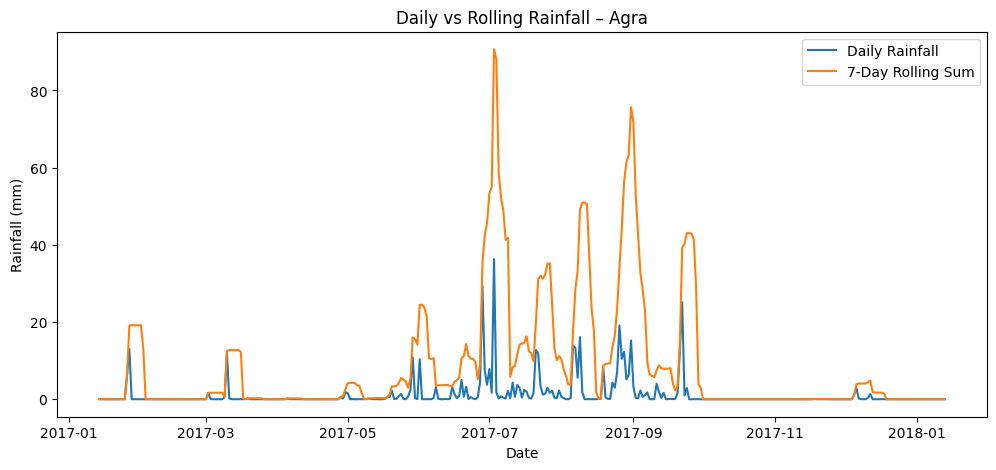

,PRECTOTCORR,rain_roll_3_sum,rain_roll_7_sum,rain_roll_3_mean,rain_roll_7_mean
0,0.0,0.0,0.06,0.0,0.008571
1,0.0,0.0,0.03,0.0,0.004286
2,0.0,0.0,0.01,0.0,0.001429
3,0.0,0.0,0.00,0.0,0.000000
4,0.0,0.0,0.00,0.0,0.000000


In [ ]:
# ==============================
# PHASE 3
# Rolling Rainfall Features
# ==============================

import matplotlib.pyplot as plt

# Ensure correct sorting
df = df.sort_values(["district", "date"])

# Rolling rainfall features (per district)
df["rain_roll_3_sum"]  = df.groupby("district")["PRECTOTCORR"].transform(lambda x: x.rolling(3).sum())
df["rain_roll_7_sum"]  = df.groupby("district")["PRECTOTCORR"].transform(lambda x: x.rolling(7).sum())
df["rain_roll_3_mean"] = df.groupby("district")["PRECTOTCORR"].transform(lambda x: x.rolling(3).mean())
df["rain_roll_7_mean"] = df.groupby("district")["PRECTOTCORR"].transform(lambda x: x.rolling(7).mean())

# Drop rows with NaNs from rolling windows
df = df.dropna().reset_index(drop=True)

print("✅ Rolling rainfall features created")
print("New shape:", df.shape)

# ------------------------------
# Visualization (Agra example)
# ------------------------------
agra = df[df["district"] == "agra"].iloc[:365]

plt.figure(figsize=(12,5))
plt.plot(agra["date"], agra["PRECTOTCORR"], label="Daily Rainfall")
plt.plot(agra["date"], agra["rain_roll_7_sum"], label="7-Day Rolling Sum")
plt.title("Daily vs Rolling Rainfall – Agra")
plt.xlabel("Date")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.show()

# Preview features
df[[
    "PRECTOTCORR",
    "rain_roll_3_sum",
    "rain_roll_7_sum",
    "rain_roll_3_mean",
    "rain_roll_7_mean"
]].head()


In [ ]:
# ================================
# Phase 3
# Derived Meteorological Features
# ================================

import numpy as np

df = df.sort_values(["district", "date"]).reset_index(drop=True)

# -----------------------------
# Temperature-based features
# -----------------------------
# Dew point depression (humidity indicator)
df["dewpoint_depression"] = df["t2m"] - df["d2m"]

# Celsius versions (more interpretable)
df["t2m_c"] = df["t2m"] - 273.15
df["d2m_c"] = df["d2m"] - 273.15

# -----------------------------
# Wind-based features
# -----------------------------
# Wind speed magnitude at 10m
df["wind_speed_10m"] = np.sqrt(df["u10"]**2 + df["v10"]**2)

# Wind direction (radians)
df["wind_dir_10m"] = np.arctan2(df["v10"], df["u10"])

# -----------------------------
# Pressure & moisture interaction
# -----------------------------
df["pressure_hpa"] = df["sp"] / 100.0
df["moisture_pressure_ratio"] = df["RH2M"] / df["pressure_hpa"]

# -----------------------------
# Simple sanity check
# -----------------------------
print("✅ Derived meteorological features created")
print("New shape:", df.shape)

df[[
    "t2m_c",
    "d2m_c",
    "dewpoint_depression",
    "wind_speed_10m",
    "pressure_hpa",
    "moisture_pressure_ratio"
]].head()


✅ Derived meteorological features created
New shape: (233424, 35)


,t2m_c,d2m_c,dewpoint_depression,wind_speed_10m,pressure_hpa,moisture_pressure_ratio
0,4.71444,3.39858,1.31586,2.428956,996.54730,0.023872
1,6.67285,5.17263,1.50022,0.790601,997.80734,0.021277
2,9.24050,7.57840,1.66210,1.887870,995.14440,0.032216
3,8.27960,6.44680,1.83280,2.828463,996.95220,0.036321
4,7.00010,6.22494,0.77516,1.988760,999.24310,0.035027


In [ ]:
# ==============================
# PHASE 3
# Feature pruning & final dataset
# ==============================

import pandas as pd
import numpy as np

# Copy to avoid accidental overwrite
df_feat = df.copy()

# -----------------------------
# 1. Separate target
# -----------------------------
TARGET_COL = "rain_t_plus_1"

y = df_feat[TARGET_COL]
X = df_feat.drop(columns=[TARGET_COL])

# -----------------------------
# 2. Remove non-feature columns
# -----------------------------
NON_FEATURE_COLS = ["date"]
X = X.drop(columns=[c for c in NON_FEATURE_COLS if c in X.columns])

# -----------------------------
# 3. Correlation with target
# -----------------------------
corr_with_target = (
    X.select_dtypes(include=[np.number])
     .corrwith(y)
     .abs()
     .sort_values(ascending=False)
)

# Keep features with meaningful correlation
selected_features = corr_with_target[corr_with_target > 0.01].index.tolist()

X = X[selected_features + ["district"]]

print("✅ Features retained after target-correlation filtering:", len(selected_features))

# -----------------------------
# 4. Remove highly correlated feature pairs
# -----------------------------
corr_matrix = X[selected_features].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [
    column for column in upper.columns
    if any(upper[column] > 0.95)
]

X = X.drop(columns=to_drop)

print("🧹 Highly correlated features removed:", len(to_drop))

# -----------------------------
# 5. Final Phase-3 dataset
# -----------------------------
final_phase3 = pd.concat([X, y], axis=1)

print("\n✅ Phase 3 feature engineering COMPLETE")
print("Final shape:", final_phase3.shape)
print("Total features (excluding target):", final_phase3.shape[1] - 1)

final_phase3.head()


✅ Features retained after target-correlation filtering: 32
🧹 Highly correlated features removed: 9

✅ Phase 3 feature engineering COMPLETE
Final shape: (233424, 25)
Total features (excluding target): 24


,PRECTOTCORR,rain_roll_3_mean,rain_roll_7_mean,T2MDEW,d2m_c,moisture_pressure_ratio,rain_lag_1,tp,t2m_c,rain_lag_3,...,wind_speed_10m,month,v10,WS10M,year,wind_dir_10m,dayofweek,day,district,rain_t_plus_1
0,0.0,0.0,0.008571,-7.99,3.39858,0.023872,0.0,0.0,4.71444,0.0,...,2.428956,1,-2.426529,1.72,2017,-1.526091,5,14,agra,0.0
1,0.0,0.0,0.004286,-7.99,5.17263,0.021277,0.0,0.0,6.67285,0.0,...,0.790601,1,-0.200729,1.87,2017,-0.256705,6,15,agra,0.0
2,0.0,0.0,0.001429,-1.78,7.57840,0.032216,0.0,0.0,9.24050,0.0,...,1.887870,1,1.740799,3.13,2017,1.968128,0,16,agra,0.0
3,0.0,0.0,0.000000,-2.64,6.44680,0.036321,0.0,0.0,8.27960,0.0,...,2.828463,1,-2.329147,3.17,2017,-0.967496,1,17,agra,0.0
4,0.0,0.0,0.000000,-2.75,6.22494,0.035027,0.0,0.0,7.00010,0.0,...,1.988760,1,-1.962204,2.40,2017,-1.407195,2,18,agra,0.0


In [ ]:
# === PHASE 3 : FINAL SAVE (AUTHORITATIVE) ===

FEATURES_PATH = "/content/drive/MyDrive/UP_Rainfall_Prediction_Project/data/features/phase3_features.csv"

final_phase3.to_csv(FEATURES_PATH, index=False)

print(" Phase 3 features saved successfully")
print(" Shape:", final_phase3.shape)
print(" Path:", FEATURES_PATH)


 Phase 3 features saved successfully
 Shape: (233424, 25)
 Path: /content/drive/MyDrive/UP_Rainfall_Prediction_Project/data/features/phase3_features.csv
